# 04 — RQ3 synthesis (consistency of winners)

Computes the pooled pairwise Wilcoxon / Holm / Vargha–Delaney A12 **once** and reuses it for: winners matrix, geomean-normalized table, ranking-stability slopegraph, non-significance clique diagram, A12 forest, and the full pairwise appendix table.

Pairwise is computed on iterations **pooled across passes** (national cells have only ~3/pass < the n≥6 Wilcoxon floor, ~9 pooled).

**Friedman omnibus has no thesis float** (it is reported inline as prose). Its value is computed, printed, and written to `tables/06-friedman-omnibus-values.json` for you to quote — no `.tex` float is fabricated.

In [1]:
import os, json
from pathlib import Path
if Path.cwd().name == "notebooks":
    os.chdir("..")
from src.plotting.style import StyleConfig
from src.analysis.tables import build_cost_summary
from src.analysis import thesis_compute as tc
from src.analysis import thesis_tables as tt
from src.plotting import thesis_figures as tf

style = StyleConfig(); style.apply_rcparams()
CACHE = os.environ.get("DOPPA_CACHE", "cache/bench-cache.duckdb")
RUN_ID = "2026-05-26-OY0CN3"
FIG = Path("figures"); TAB = Path("tables")

experiments, samples_df, metadata_df, costs_df, successful = tc.load_all(
    CACHE, "../doppa/benchmarks.yml", RUN_ID)
cost_summary = build_cost_summary(costs_df)
pooled = tc.pooled_pairwise_table(successful)
sysvals = tc.rq3_system_values(successful, cost_summary)
geomean = tc.rq3_geomean(sysvals)
winners = tc.rq3_winners(sysvals)
ranks = tc.rq3_ranks(sysvals)
print("pooled pairwise rows:", len(pooled))

pooled pairwise rows: 327


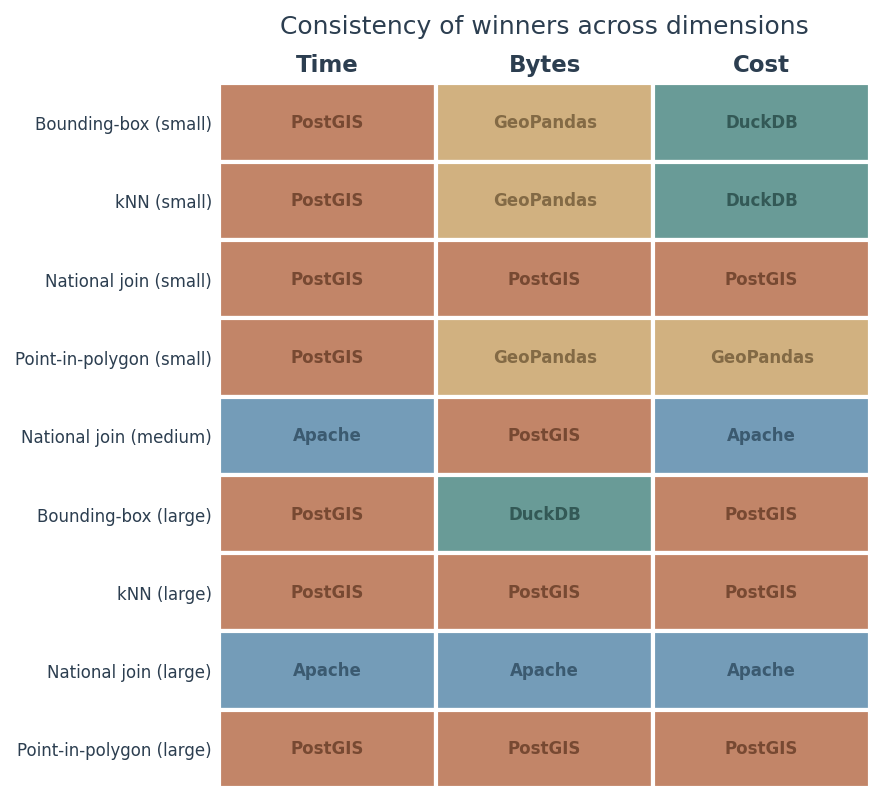

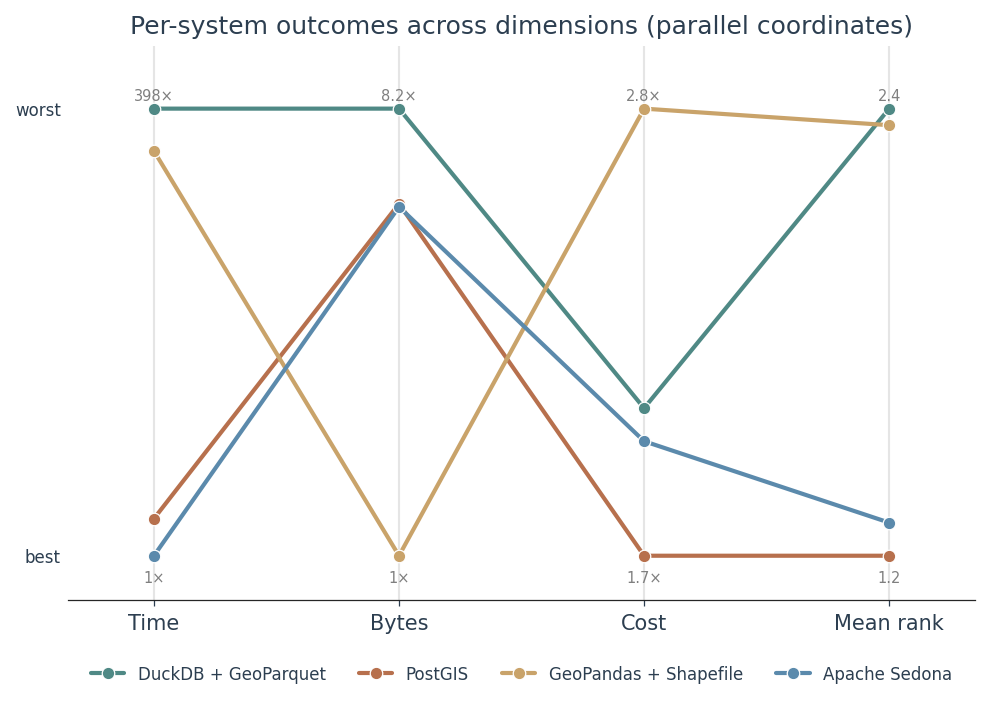

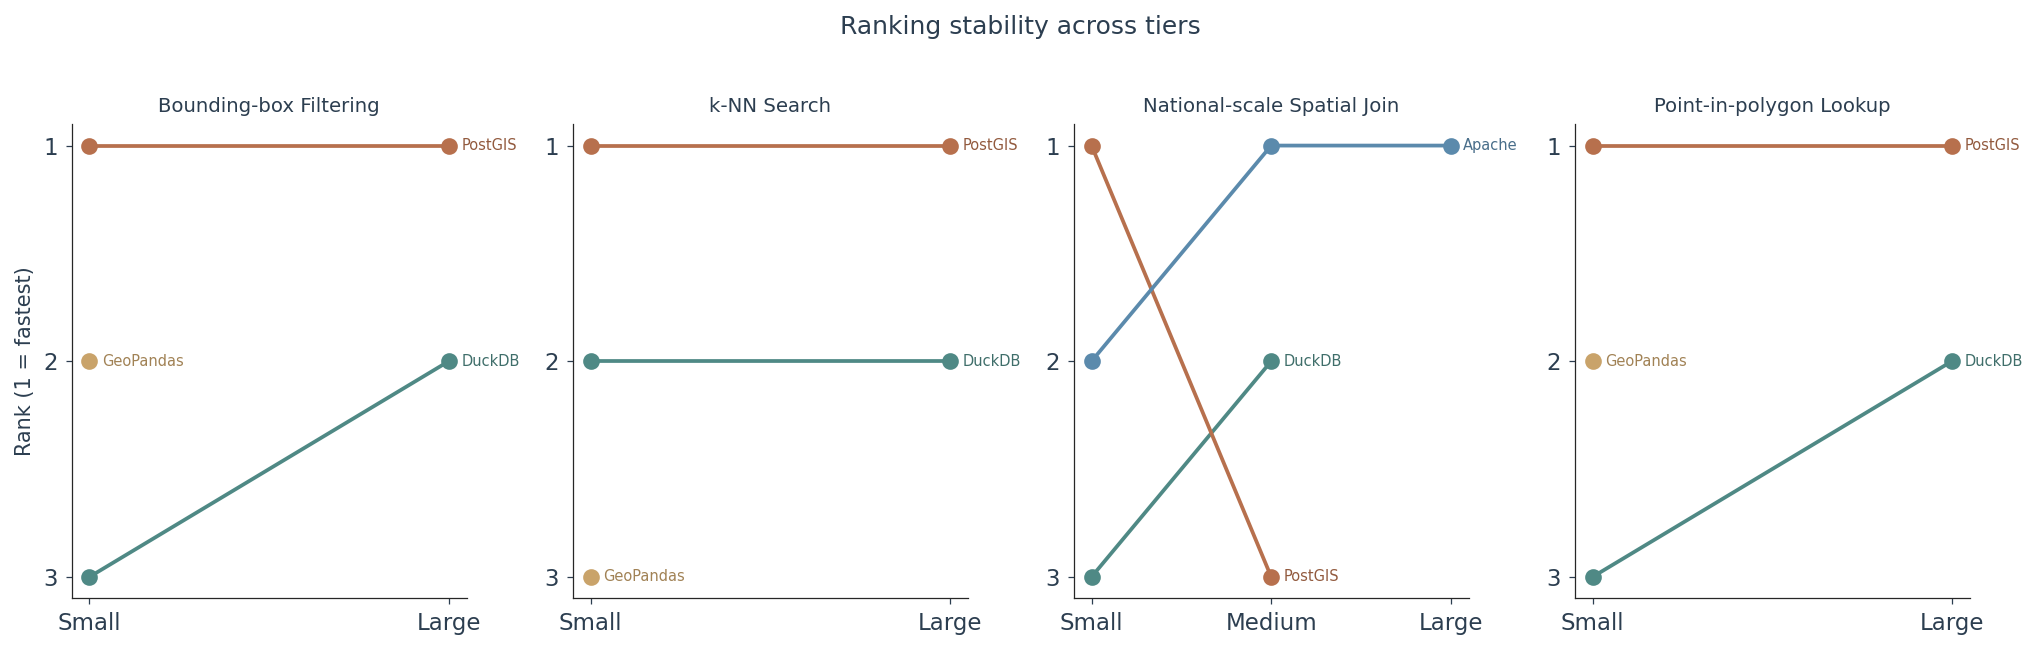

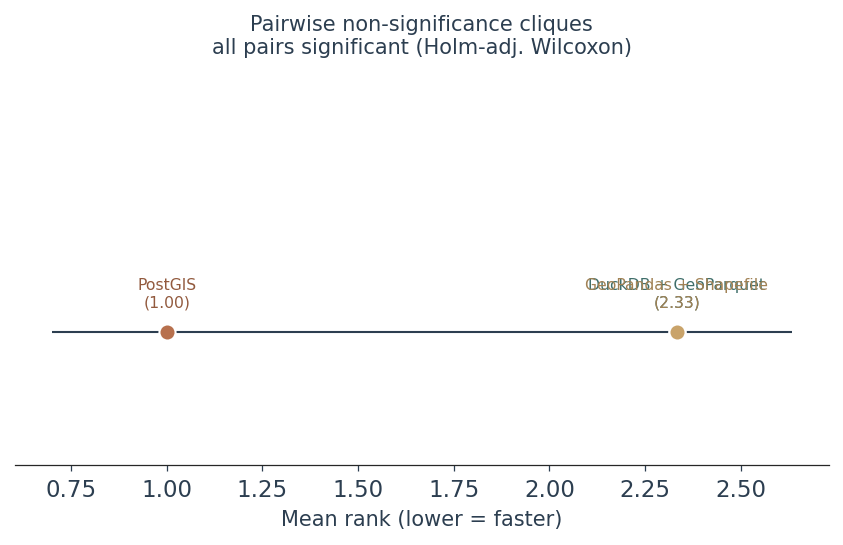

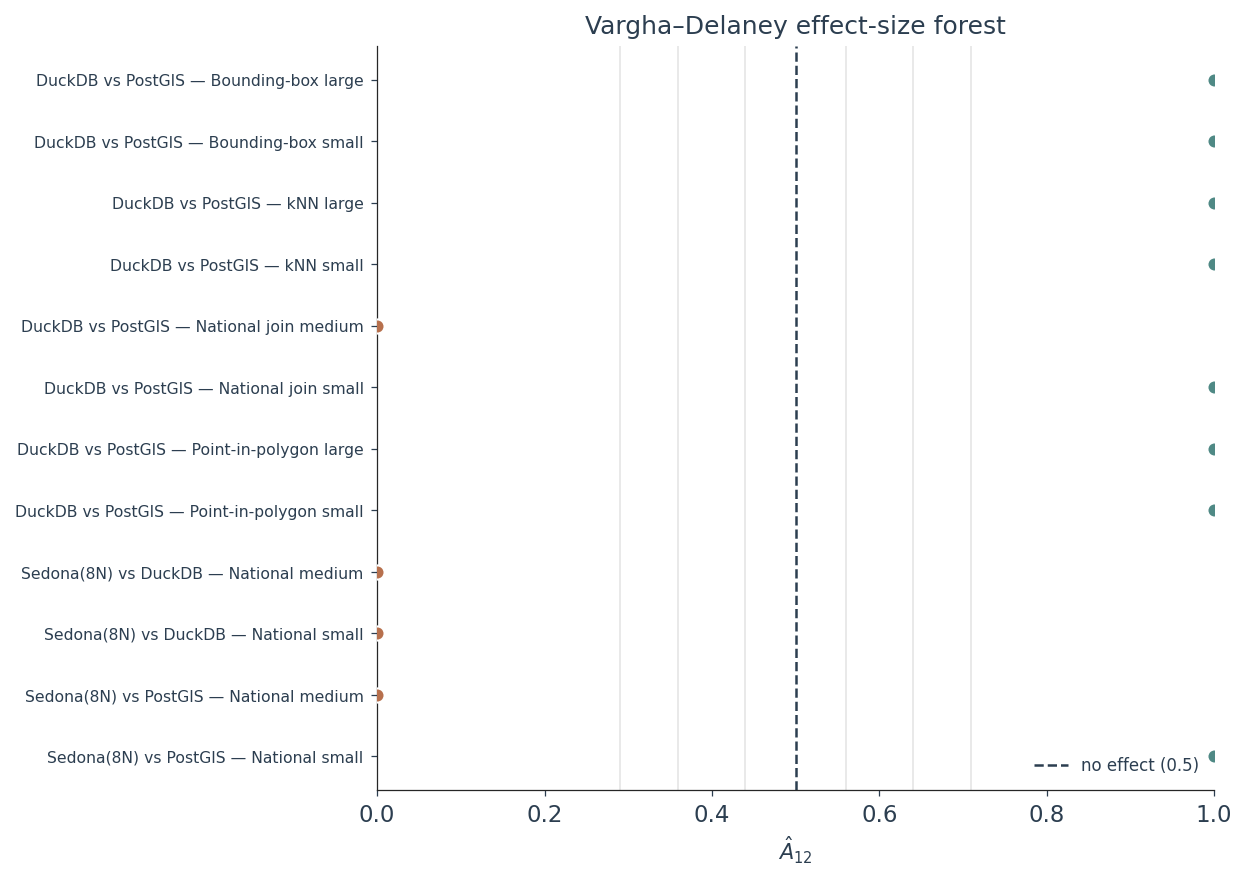

PosixPath('figures/06-vargha-delaney-forest.png')

In [2]:
tf.fig_winners_matrix(winners, style, FIG / "06-winners-matrix.png")
paxes = tc.rq3_parallel_axes(geomean, ranks)
tf.fig_rq3_parallel_coords(paxes, style, FIG / "06-outcome-parallel-coordinates.png")
tf.fig_ranking_stability(ranks, style, FIG / "06-ranking-stability.png")
mean_ranks, nonsig = tc.rq1_cliques(successful, pooled)
tf.fig_cliques(mean_ranks, nonsig, style, FIG / "06-pairwise-significance-cliques.png")
forest = tc.a12_forest(pooled)
tf.fig_a12_forest(forest, style, FIG / "06-vargha-delaney-forest.png")

## Tables: geomean, full pairwise; Friedman value (no float)

In [3]:
tt.emit_geomean(geomean, TAB / "06-rq3-geomean.tex")
tt.emit_pairwise(tc.format_pairwise_for_table(pooled), TAB / "08-pairwise-statistics.tex")
fr = tc.friedman_summary(pooled)
print("Friedman omnibus (for prose):", fr)
(TAB / "06-friedman-omnibus-values.json").write_text(json.dumps(fr, indent=2))
display(geomean); display(winners)

Friedman omnibus (for prose): {'workload': 'point-in-polygon-lookup', 'tier': 'small', 'metric': 'elapsed_time', 'chi2': 2564.0, 'p': 0.0, 'df': 2, 'k_configs': 3, 'n_blocks': 1282}


,Time,Bytes,Cost
duckdb,398.454421,8.232309,1.995262
postgis,1.657716,5.258874,1.699407
local,226.103463,1.000000,2.763804
sedona,1.009435,5.181509,1.924834


,Time,Bytes,Cost
Bounding-box (small),postgis,local,duckdb
kNN (small),postgis,local,duckdb
National join (small),postgis,postgis,postgis
Point-in-polygon (small),postgis,local,local
National join (medium),sedona,postgis,sedona
Bounding-box (large),postgis,duckdb,postgis
kNN (large),postgis,postgis,postgis
National join (large),sedona,sedona,sedona
Point-in-polygon (large),postgis,postgis,postgis
